# Network Analysis
## Lab 4
### Linear Network Models

In this lab, we study how linear network models can approximate complex outcomes and generate amplification, spillovers, as well as long-run equilibrium outcomes. A single mathematical structure underlies all these applications:
\begin{align*}
    \begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix} & = \begin{bmatrix} \alpha_1 \\ \vdots \\ \alpha_n \end{bmatrix} + \beta \cdot \begin{bmatrix} A_{1,1} & \cdots & A_{1, n} \\ \vdots & \ddots & \vdots \\ A_{n,1} & \cdots & A_{n, n} \end{bmatrix} \begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix} \\
    y & = \alpha + \beta \cdot A y
\end{align*}

Depending on interpretation, this equation can represent for example:
- Peer effects in education
- Recursive influence (Katz–Bonacich centrality)
- Production multipliers in input–output networks
- Many others

We will:
1. Construct structured deterministic networks.
2. Study repeated linear updating and convergence.
3. Connect stability to the size of entries of A (spectral radius).
4. Apply the same framework to a Leontief production network.
5. Simulate shocks and study return to equilibrium.

The goal is to understand how network structure governs amplification and stability. Our first application concerns **peer effects in education**.

In [105]:
import numpy as np
import igraph as ig
import matplotlib.pyplot as plt

12


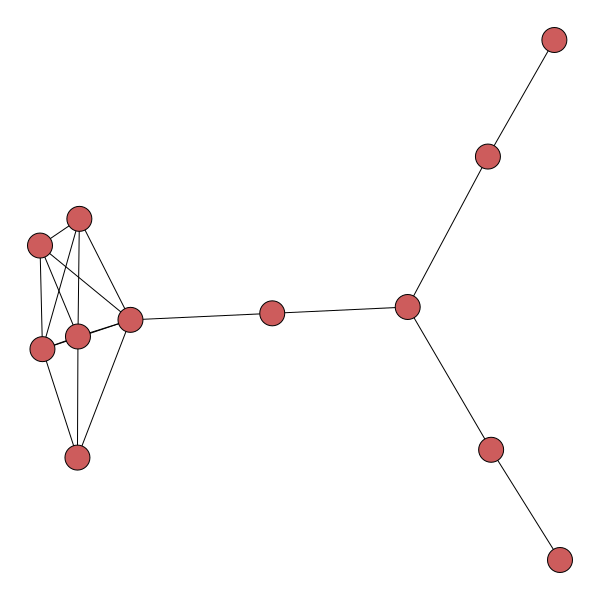

In [106]:
# Construct study network
# Define edges manually
edges = [
    # Core clique (0-4)
    (0,1),(1,2),(2,3),(3,4),(4,0),
    (0,2),(1,3),(2,4),(3,0),(4,1),

    # Peripheral chain (5-9)
    (5,6),(6,7),(7,8),(8,9),

    # Bridge node
    (2,10),(10,7),

    # Influencer
    (11,0),(11,1),(11,2)
]

G = ig.Graph(edges=edges, directed=False)
n = G.vcount()
print(n)

layout = G.layout("fr")

ig.plot(
    G,
    layout=layout,
    vertex_size=25,
    vertex_color="indianred",
    edge_color="black",
    bbox=(600,600),
    margin=40
)


### Education peer effects

We model repeated exams:
\begin{equation*}
    y^{(t+1)} = \alpha + \beta A y^{(t)}
\end{equation*}

- $\alpha$: baseline ability for each student
- $\beta$: strength of peer effects
- $A$: row-normalized adjacency (study) matrix

We simulate repeated updates and observe convergence.

0.2638888888888889
0.08333333333333333


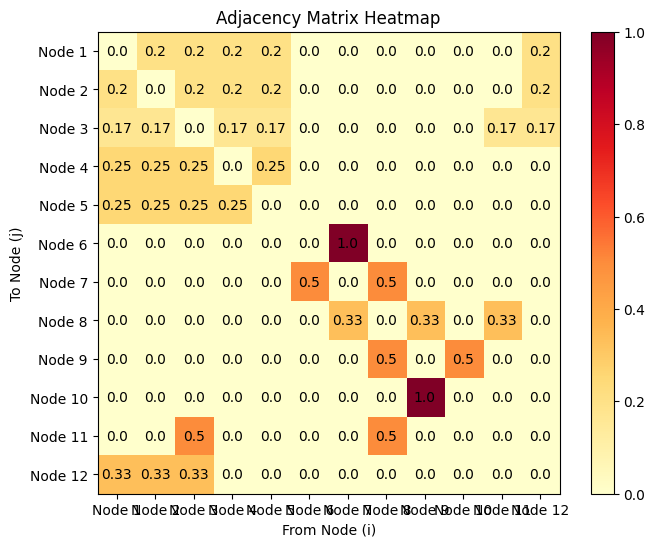

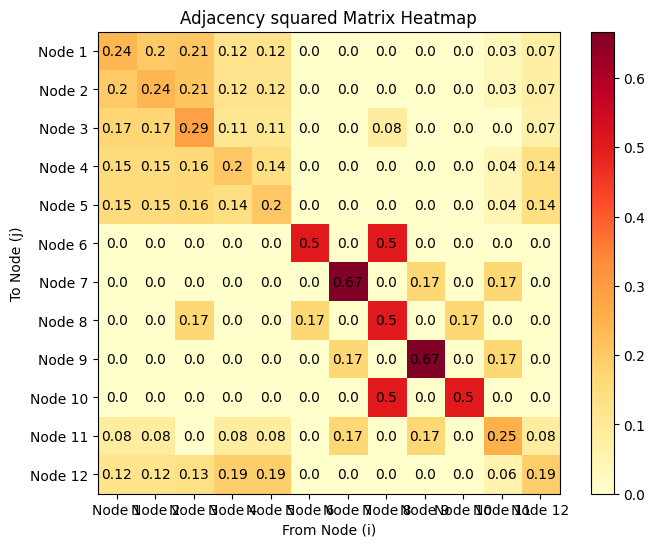

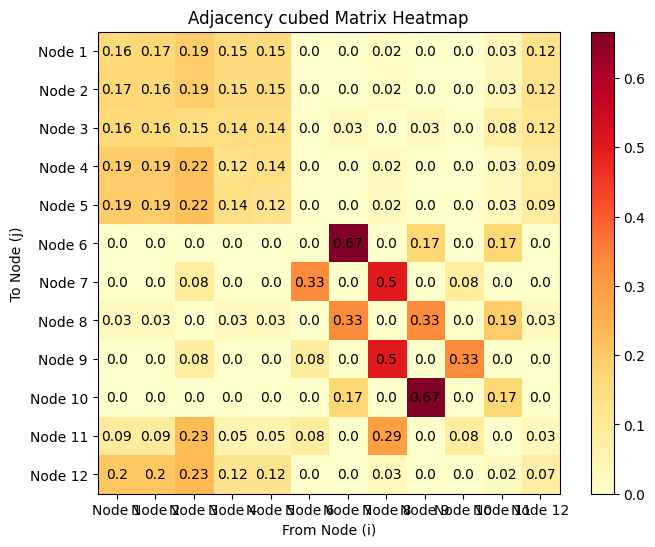

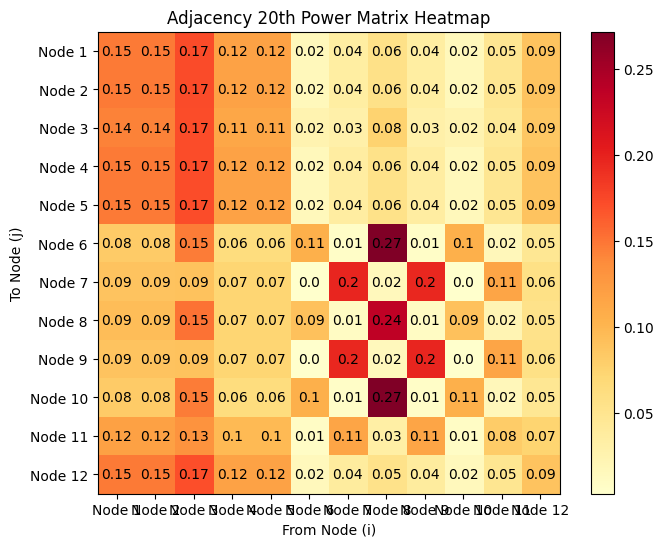

In [107]:
# Build row-normalized adjacency
A = np.array(G.get_adjacency().data, dtype=float)
row_sums = A.sum(axis=1)
row_sums[row_sums == 0] = 1
A_normalized = A / row_sums[:, None]
print(np.mean(A))
print(np.mean(A_normalized))

# Visualize heatmap of adjacency and second order connections
plt.figure(figsize=(8, 6))
plt.imshow(A_normalized, cmap='YlOrRd')
plt.colorbar()
plt.xticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
plt.yticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
for i in range(n):
    for j in range(n):
        plt.text(j, i, np.round(A_normalized[i, j], 2), ha='center', va='center', color='black')
plt.title("Adjacency Matrix Heatmap")
plt.xlabel("From Node (i)")
plt.ylabel("To Node (j)")
plt.show()

A_squared = A_normalized @ A_normalized
plt.figure(figsize=(8, 6))
plt.imshow(A_squared, cmap='YlOrRd')
plt.colorbar()
plt.xticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
plt.yticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
for i in range(n):
    for j in range(n):
        plt.text(j, i, np.round(A_squared[i, j], 2), ha='center', va='center', color='black')
plt.title("Adjacency squared Matrix Heatmap")
plt.xlabel("From Node (i)")
plt.ylabel("To Node (j)")
plt.show()

A_cubed = A_squared @ A_normalized
plt.figure(figsize=(8, 6))
plt.imshow(A_cubed, cmap='YlOrRd')
plt.colorbar()
plt.xticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
plt.yticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
for i in range(n):
    for j in range(n):
        plt.text(j, i, np.round(A_cubed[i, j], 2), ha='center', va='center', color='black')
plt.title("Adjacency cubed Matrix Heatmap")
plt.xlabel("From Node (i)")
plt.ylabel("To Node (j)")
plt.show()

A_20 = np.linalg.matrix_power(A_normalized, 20)
plt.figure(figsize=(8, 6))
plt.imshow(A_20, cmap='YlOrRd')
plt.colorbar()
plt.xticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
plt.yticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
for i in range(n):
    for j in range(n):
        plt.text(j, i, np.round(A_20[i, j], 2), ha='center', va='center', color='black')
plt.title("Adjacency 20th Power Matrix Heatmap")
plt.xlabel("From Node (i)")
plt.ylabel("To Node (j)")
plt.show()

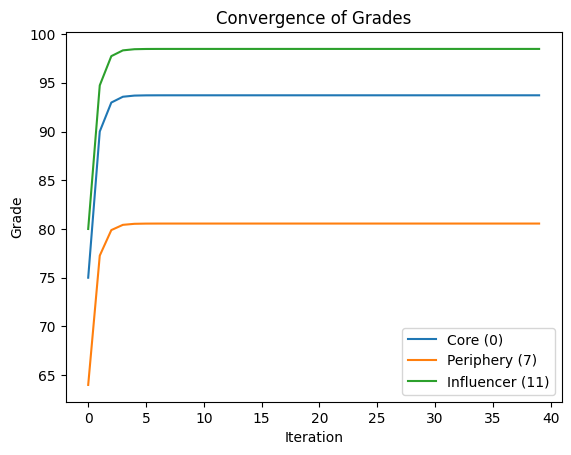

In [108]:
# Baseline abilities
a = np.array([75,72,74,73,76,65,66,64,63,62,70,80])
b = 0.2

# Save history of grades
n_repetitions = 40
y = np.zeros(12)
history = np.zeros([n_repetitions, n])
for t in range(n_repetitions):
    y = a + b * A_normalized @ y
    history[t] = y.copy()

# Plot convergence for selected students
plt.plot(history[:,0], label="Core (0)")
plt.plot(history[:,7], label="Periphery (7)")
plt.plot(history[:,11], label="Influencer (11)")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Grade")
plt.title("Convergence of Grades")
plt.show()

### Centrality and influence

Reinterpret the same network as an influence network. Katz centrality solves:
\being{align*}
    c & = \alpha \mathbf{1}_n + \beta \cdot A c \\
    c & = \alpha \cdot (I_n - \beta \cdot A)^{-1} \mathbf{1}_n
\end{align*}
This counts all walks in the network, discounting longer paths and assigning the equilibrium influence as the final centrality measure.


In [109]:
# Katz-Bonacich centrality parameters
alpha = 1
beta = 0.2

# Compute equilibrium influence directly
I = np.eye(n)
ones = np.ones(n)
c_katz = alpha * np.linalg.solve(I - beta*A_normalized, ones)
unormalized_katz = alpha * np.linalg.solve(I - beta*A, ones)
print(c_katz)
print(unormalized_katz)

[1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25]
[10.62167241 10.62167241 11.24491074  9.37206389  9.37206389  1.35217664
  1.76088318  2.45223927  1.76088318  1.35217664  3.73943     7.49765111]


Convergence in linear network models requires the entries of A to be "small enough". This can be measured in terms of the **spectral radius** of $A$, denoted as $\rho(A)$. It is the absolute value of the largest eigenvalue of $A$. If
\begin{align*}
    \rho(\beta \cdot A) < 1 \\
    \rho(A) < \frac{1}{\beta}
\end{align*}
the repeated application of $\beta \cdot A$ converges. We can easily compute this ratio in practice.

In [116]:
# Compute spectral radius directly
eigvals = np.linalg.eigvals(A_normalized)
rho = max(abs(eigvals))

print("Spectral radius:", rho)
print("Stability requires rho < 1/beta -->", (rho < 1/beta))

Spectral radius: 1.0
Stability requires rho < 1/beta --> True


### Leontief Demand process

We now apply the same structure to a production network. Leontief model:
\begin{align*}
    y = d + A y
\end{align*}

- $d$: final demand
- $A$: technical coefficients (how sectors supply to their buyers to produce output)
- $y$: gross output

We extract a 10×10 block from the US 2002 IO matrix and rescale it.

In [117]:
# Load data as a Matlab .mat file
from scipy.io import loadmat

# Load .mat file
mat_data = loadmat('IO2002_data.mat')
# mat_data is a dictionary where keys are variable names
print(mat_data.keys())  # See what variables are in the file

# Access specific matrix/variable
IO_matrix = mat_data['CC02']
print(IO_matrix.shape)

# Focus only on the 10x10 upper left block and rescale
# Assume IO_full exists
A10 = IO_matrix[:10, :10].copy()

row_sums = A10.sum(axis=1)
row_sums[row_sums == 0] = 1
A10 = 0.7 * A10 / row_sums[:, None]

dict_keys(['__header__', '__version__', '__globals__', 'CC02'])
(417, 417)


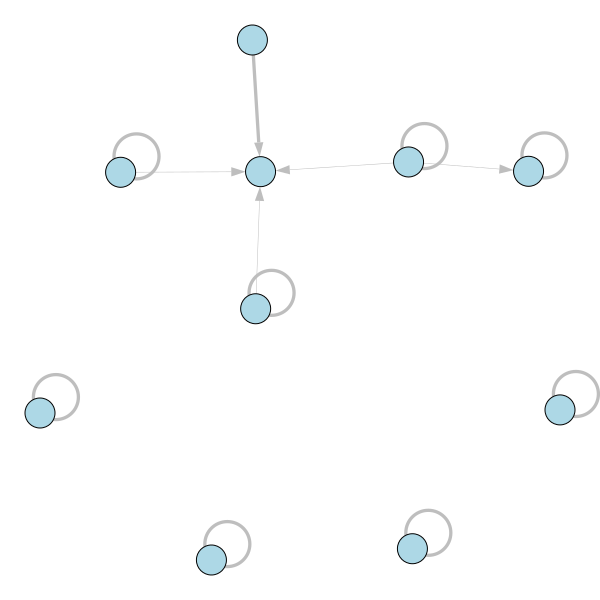

In [118]:
# Extract and visualize IO matrix
G_io = ig.Graph.Weighted_Adjacency(
    A10.tolist(),
    mode="directed",
    attr="weight"
)

ig.plot( G_io, layout="fr", vertex_size=30, vertex_color="lightblue", edge_color="gray", edge_width=[0.5 + 4 * w for w in G_io.es["weight"]], bbox=(600,600), margin=40 )


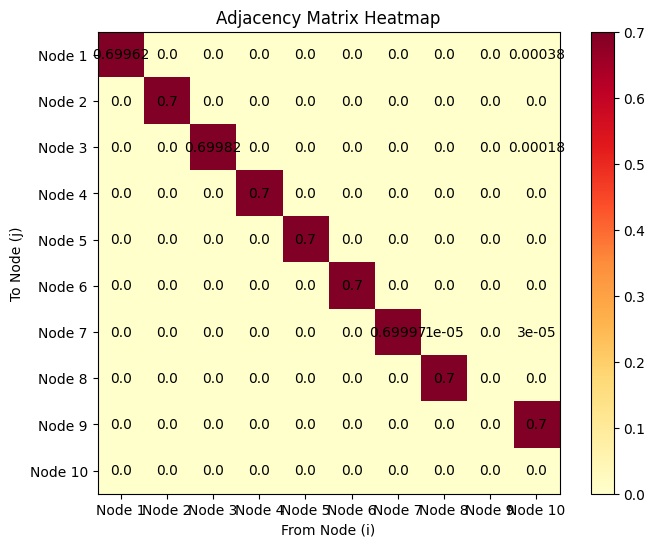

In [113]:
# Visualize IO matrix
n = 10
plt.figure(figsize=(8, 6))
plt.imshow(A10, cmap='YlOrRd')
plt.colorbar()
plt.xticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
plt.yticks(ticks=np.arange(n), labels=[f"Node {i+1}" for i in range(n)])
for i in range(n):
    for j in range(n):
        plt.text(j, i, np.round(A10[i, j], 5), ha='center', va='center', color='black')
plt.title("Adjacency Matrix Heatmap")
plt.xlabel("From Node (i)")
plt.ylabel("To Node (j)")
plt.show()

[66.59793018 50.         33.32127623 40.         26.66666667 46.66666667
 29.99856725 36.66666667 16.1        13.        ]


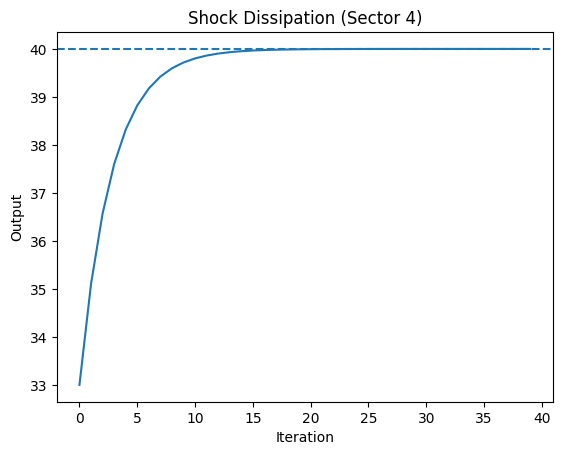

In [120]:
# Equilibrium behaviour given initial demands
d = np.array([20,15,10,12,8,14,9,11,7,13])

I10 = np.eye(10)
y_star = np.linalg.solve(I10 - A10, d)
print(y_star)

# Introduce shock
y_current = y_star.copy()
y_current[3] -= 10

trajectory = []

for t in range(40):
    y_current = d + A10 @ y_current
    trajectory.append(y_current.copy())

trajectory = np.array(trajectory)

# Plot return to equilibrium
plt.plot(trajectory[:,3])
plt.axhline(y_star[3], linestyle="--")
plt.xlabel("Iteration")
plt.ylabel("Output")
plt.title("Shock Dissipation (Sector 4)")
plt.show()
